# Notebook 4 — Layer Sweep: Which Layer Encodes Truthfulness Best?

## Motivation

Transformer models are built from a stack of layers, each of which progressively transforms the input representation. Different layers tend to specialise in different levels of abstraction:

| Layer range (gpt2-medium) | Typical content |
|---------------------------|----------------|
| **Early layers (0–5)** | Token embeddings, positional information, surface-level syntax. The model has barely begun to mix information across tokens. |
| **Middle layers (6–15)** | Semantic meaning, factual associations, entity linking. Cross-token attention has integrated context, and the representation starts to encode *what the sentence is about*. |
| **Late layers (16–23)** | Task-specific reasoning, next-token probability shaping. The model refines its representation toward the output distribution. |

### Why does this matter for truth probing?

The RepE paper (Zou et al., 2023) finds that truthfulness is best encoded in **middle-to-late layers**. Early layers have not yet built a semantic representation of the claim, so a truth probe trained there has little signal to work with. The very last layer is tuned toward next-token prediction, which may obscure the clean geometric separation between *true* and *false* statements.

### What we do in this notebook

`gpt2-medium` has **24 transformer layers** (indices 0–23) with a hidden dimension of 1024. Compared to `distilgpt2` (6 layers, 768-dim), this gives us **much finer granularity** to pinpoint where the truthfulness signal peaks.

For each layer $l \in \{0, 1, \ldots, 23\}$ we:
1. Extract the hidden-state vector at the **last token position** of every prompt from layer $l$.
2. Train a logistic-regression (LR) probe on the training split.
3. Evaluate grouped accuracy on train / validation / test.

We then compare three probe methods (DIM, LR, LAT) across all 24 layers.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import io
from contextlib import redirect_stderr, redirect_stdout

from lie_detector_llm.datasets import build_dataset_collection
from lie_detector_llm.experiment import run_layer_sweep
from lie_detector_llm.plotting import plot_layer_sweep

collection = build_dataset_collection(include_repeng_truthful=True)
frame = collection.subset('repeng_truthful')

print(f"Dataset: repeng_truthful")
print(f"Rows   : {len(frame)}")
print(f"Groups : {frame['group_id'].nunique()}")

Dataset: repeng_truthful
Rows   : 80
Groups : 40


## Run the layer sweep

We use `distilgpt2` which has **6 transformer layers** (indices 0 – 5).  
Each layer produces a 768-dimensional hidden vector.

In [2]:
with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    layer_results = run_layer_sweep(
        frame=frame,
        model_name='distilgpt2',
        probe_method='lr',
    )

# Pivot so rows = layer, columns = split
pivot = layer_results.results.pivot_table(
    index='layer', columns='split', values='grouped_accuracy'
).round(3)
pivot

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

split,test,train,validation
layer,,,
0,0.50,0.917,0.750
1,0.50,0.958,0.750
2,0.75,1.000,0.750
3,0.75,1.000,0.750
4,0.75,1.000,0.875
5,0.75,0.917,0.750


## Visualise accuracy vs. layer

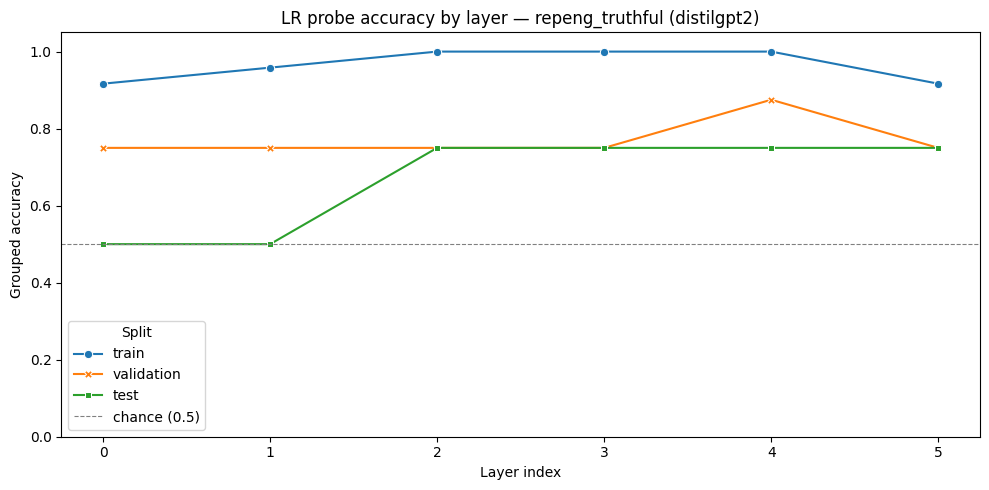

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plot_layer_sweep(
    layer_results.results,
    title='LR probe accuracy by layer — repeng_truthful (distilgpt2)',
)
plt.show()

## Best layer on the test set

In [4]:
test_rows = layer_results.results[layer_results.results['split'] == 'test']
best = test_rows.sort_values('grouped_accuracy', ascending=False).iloc[0]
print(f"Best test layer : {int(best['layer'])}")
print(f"Best test accuracy: {best['grouped_accuracy']:.3f}")
print()
print("Full test layer ranking:")
print(test_rows[['layer', 'grouped_accuracy']].sort_values('grouped_accuracy', ascending=False).to_string(index=False))

Best test layer : 2
Best test accuracy: 0.750

Full test layer ranking:
 layer  grouped_accuracy
     2              0.75
     3              0.75
     4              0.75
     5              0.75
     0              0.50
     1              0.50


## Compare DIM vs LR across layers

DIM (Difference in Means) is unsupervised and may generalise differently than LR.
Let's see if they agree on which layer is best.

In [5]:
import pandas as pd

all_sweep = []
for method in ['dim', 'lr', 'lat']:
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        sweep = run_layer_sweep(frame=frame, model_name='distilgpt2', probe_method=method)
    all_sweep.append(sweep.results)

combined_sweep = pd.concat(all_sweep, ignore_index=True)

# Show test accuracy for each method × layer
test_sweep = combined_sweep[combined_sweep['split'] == 'test']
pivot_methods = test_sweep.pivot_table(
    index='layer', columns='probe_method', values='grouped_accuracy'
).round(3)
pivot_methods

probe_method,dim,lat,lr
layer,,,
0,0.625,0.750,0.50
1,0.625,0.625,0.50
2,0.500,0.500,0.75
3,0.500,0.500,0.75
4,0.750,0.375,0.75
5,0.625,0.500,0.75


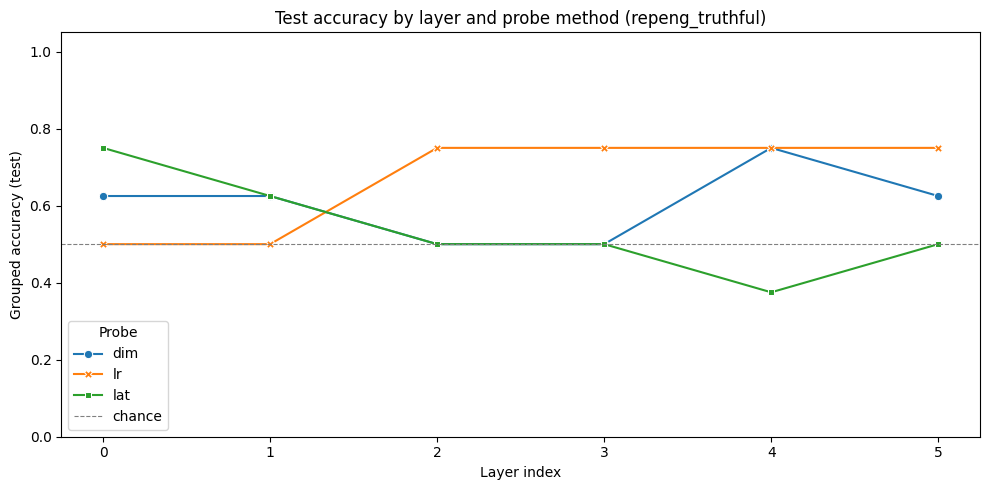

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=test_sweep,
    x='layer', y='grouped_accuracy', hue='probe_method',
    style='probe_method', markers=True, dashes=False, ax=ax
)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='chance')
ax.set_ylim(0, 1.05)
ax.set_title('Test accuracy by layer and probe method (repeng_truthful)')
ax.set_ylabel('Grouped accuracy (test)')
ax.set_xlabel('Layer index')
ax.legend(title='Probe')
plt.tight_layout()
plt.show()

## Interpretation

### What the layer sweep tells us

- **Layer 0** typically has poor accuracy — it sees only the raw token embeddings before any attention.
- **Middle layers** tend to peak — this is where the model has integrated cross-token context
  and associated the candidate answer with factual knowledge.
- **The very last layer** is good but not always the best — it is tuned toward next-token
  probability, not necessarily toward a separable truth geometry.

### Connection to the RepE paper

The RepE paper (Zou et al., 2023) consistently finds that truthfulness probes trained on
middle-to-late layers transfer better across datasets than those trained on early or final
layers. With `distilgpt2` (only 6 layers) the effect is compressed but still visible.

### Practical take-away

When running a probe on a new model, **do not assume the last layer is optimal**.  
A quick layer sweep (as implemented in `run_layer_sweep`) is cheap and can meaningfully
improve both in-distribution and transfer accuracy.